In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("IMDB-Movie-Data.csv")

# Preview
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore,Unnamed: 12
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074.0,333.13,76.0,NaN
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820.0,126.46,65.0,NaN
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606.0,138.12,62.0,NaN
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545.0,270.32,59.0,NaN
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727.0,325.02,40.0,NaN


In [6]:
# Check missing values
df.isnull().sum()



Rank                    0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)      0
Metascore               0
Unnamed: 12           998
dtype: int64

In [7]:
# Encode categorical variables
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actors'] = le.fit_transform(df['Actors'])

In [8]:
X = df.drop('Rating', axis=1)
y = df['Rating']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
print(X_train.dtypes)

Rank                    int64
Genre                   int64
Description               str
Director                int64
Actors                  int64
Year                      str
Runtime (Minutes)       int64
Votes                 float64
Revenue (Millions)    float64
Metascore             float64
Unnamed: 12           float64
dtype: object


In [14]:
from sklearn.ensemble import RandomForestRegressor

# Keep only numeric columns
X_train_clean = X_train.select_dtypes(include=['number'])
X_test_clean = X_test.select_dtypes(include=['number'])

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Fit model
rf_model.fit(X_train_clean, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_clean)def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name} Performance:")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 30)

evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
features = X.columns

if len(features) != len(importances):
    print(f"Mismatch: {len(features)} feature names, {len(importances)} importances")
else:
    feat_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_df)
    plt.title("Feature Importance (Random Forest)")
    plt.show()

Mismatch: 11 feature names, 9 importances


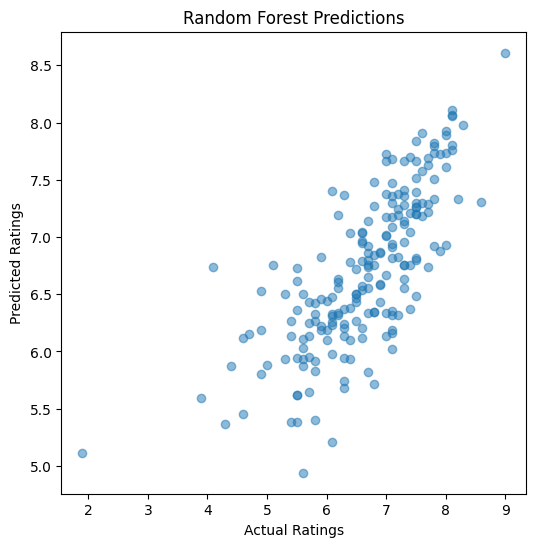

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Random Forest Predictions")
plt.show()